# Model Comparison: YOLOv8m vs MobileNet vs MobileNet+YOLOv8m

This notebook compares the performance of three face mask detection models:
- **YOLOv8m v2**: Object detection model (face_mask_detection_yolov8m_v2_best.pt)
- **MobileNet**: Classification model trained on ground truth boxes (face_mask_mobilenet_best.h5)
- **MobileNet+YOLOv8m**: Classification model trained on YOLOv8m detected faces (face_mask_mobilenet_yolov8m_best.h5)

## How to Calculate Model Parameters

**Formula for Dense/Fully Connected Layers:**
```
Parameters = (input_size × output_size) + output_size
           = (input_size × output_size) + bias_terms
```

**Example: Dense(256) after 1280 inputs:**
```
Parameters = (1280 × 256) + 256 = 327,936
```

**Formula for Convolutional Layers:**
```
Parameters = (kernel_height × kernel_width × input_channels × output_channels) + output_channels
```

**Example: Conv2D(3×3, input=32, output=64):**
```
Parameters = (3 × 3 × 32 × 64) + 64 = 18,496
```

**Formula for Batch Normalization:**
```
Parameters = 2 × num_features  (scale + shift parameters)
           + 2 × num_features  (running mean + variance, not trainable)
```

**Example: BatchNorm(256 features):**
```
Parameters = 2 × 256 = 512 (trainable)
```

**Layers with NO Parameters:**
- Activation layers (ReLU, Sigmoid, etc.)
- Dropout layers
- GlobalAveragePooling layers
- Max/Average Pooling layers

In [128]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# Define paths
BASE_DIR = Path('/Users/khoanguyen/Workspace/UIT/face_mask_detection')
YOLOV8_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolo26m_v1_best.pt'
MOBILENET_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_mobilenet_best.h5'
MOBILENET_YOLOV8_MODEL_PATH = BASE_DIR / 'models' / 'face_mask_mobilenet_best.h5'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

print(f"YOLOv8 model exists: {YOLOV8_MODEL_PATH.exists()}")
print(f"MobileNet (GT boxes) model exists: {MOBILENET_MODEL_PATH.exists()}")
print(f"MobileNet (YOLOv8) model exists: {MOBILENET_YOLOV8_MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

YOLOv8 model exists: True
MobileNet (GT boxes) model exists: True
MobileNet (YOLOv8) model exists: True
Test images directory exists: True
Test labels directory exists: True


In [130]:
# Load models
print("Loading YOLOv8 model...")
yolo_model = YOLO(str(YOLOV8_MODEL_PATH))

print("Loading MobileNet model (trained on ground truth boxes)...")
mobilenet_model = keras.models.load_model(str(MOBILENET_MODEL_PATH), compile=False)

print("Loading MobileNet+YOLOv8m model (trained on YOLOv8m detections)...")
mobilenet_yolov8_model = keras.models.load_model(str(MOBILENET_YOLOV8_MODEL_PATH), compile=False)

print("All models loaded successfully!")

Loading YOLOv8 model...
Loading MobileNet model (trained on ground truth boxes)...
Loading MobileNet+YOLOv8m model (trained on YOLOv8m detections)...
All models loaded successfully!


In [131]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

print("Sample test image paths:")
for img in test_images[:3]:
    print(f"  {img.name}")

Found 578 test images
Sample test image paths:
  0020.jpg
  0049.jpg
  0054.jpg


## YOLOv8m Model Evaluation

Detection performance of the YOLOv8m v2 model trained with class imbalance weighting and augmentation.


In [132]:
# YOLOv8 Predictions
print("Running YOLOv8 predictions on test set...")

yolo_y_true = []
yolo_y_pred = []
yolo_confidences = []

for img_path in tqdm(test_images):
    # Get ground truth
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Run prediction
    results = yolo_model(str(img_path), verbose=False)
    
    # Extract predictions
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                yolo_y_pred.append(pred_class)
                yolo_confidences.append(confidence)
    
    # Extract ground truth (one label per detection)
    for gt_class, _, _, _, _ in gt_labels:
        yolo_y_true.append(gt_class)

# Handle case where number of predictions doesn't match ground truth
min_len = min(len(yolo_y_true), len(yolo_y_pred))
yolo_y_true = yolo_y_true[:min_len]
yolo_y_pred = yolo_y_pred[:min_len]
yolo_confidences = yolo_confidences[:min_len]

print(f"YOLOv8 - Total predictions: {len(yolo_y_pred)}")
print(f"YOLOv8 - Total ground truth: {len(yolo_y_true)}")

Running YOLOv8 predictions on test set...


100%|██████████| 578/578 [00:11<00:00, 51.09it/s]

YOLOv8 - Total predictions: 1393
YOLOv8 - Total ground truth: 1393


In [133]:
# Calculate YOLOv8 metrics
yolo_accuracy = accuracy_score(yolo_y_true, yolo_y_pred)
yolo_precision = precision_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)
yolo_recall = recall_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)
yolo_f1 = f1_score(yolo_y_true, yolo_y_pred, average='weighted', zero_division=0)

# Per-class metrics
yolo_precision_per_class = precision_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)
yolo_recall_per_class = recall_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)
yolo_f1_per_class = f1_score(yolo_y_true, yolo_y_pred, average=None, zero_division=0)

print("YOLOv8 Model Metrics:")
print(f"  Accuracy:  {yolo_accuracy:.4f}")
print(f"  Precision: {yolo_precision:.4f}")
print(f"  Recall:    {yolo_recall:.4f}")
print(f"  F1-Score:  {yolo_f1:.4f}")
print(f"  Avg Confidence: {np.mean(yolo_confidences):.4f}")
print("\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(yolo_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {yolo_precision_per_class[i]:.4f}")
        print(f"    Recall:    {yolo_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {yolo_f1_per_class[i]:.4f}")

YOLOv8 Model Metrics:
  Accuracy:  0.7344
  Precision: 0.7322
  Recall:    0.7344
  F1-Score:  0.7330
  Avg Confidence: 0.6547

Per-class metrics:
  With Mask:
    Precision: 0.8389
    Recall:    0.8336
    F1-Score:  0.8363
  Without Mask:
    Precision: 0.3650
    Recall:    0.4049
    F1-Score:  0.3839
  Mask Weared Incorrect:
    Precision: 0.0500
    Recall:    0.0250
    F1-Score:  0.0333


## MobileNet Model Evaluation

This section evaluates two MobileNet variants:
- **MobileNet (GT)**: Classification on ground truth bounding boxes
- **MobileNet+YOLOv8m**: Classification model trained on YOLOv8m detected faces

Both models are evaluated on the same test set using ground truth bounding boxes for fair comparison.


In [134]:
# MobileNet Predictions
print("Running MobileNet predictions on test set using ground truth bounding boxes...")

mobilenet_y_true = []
mobilenet_y_pred = []
mobilenet_confidences = []

# Image size for MobileNet (need to check what size it was trained on)
IMG_SIZE = 192  # MobileNet was trained with 192x192 input

def convert_yolo_to_pixel_coords(bbox_yolo, img_w, img_h):
    """Convert YOLO format bbox (normalized center_x, center_y, width, height) to pixel coordinates (x1, y1, x2, y2)"""
    center_x, center_y, bbox_w, bbox_h = bbox_yolo
    
    # Convert from normalized to pixel coordinates
    pixel_center_x = center_x * img_w
    pixel_center_y = center_y * img_h
    pixel_width = bbox_w * img_w
    pixel_height = bbox_h * img_h
    
    # Calculate top-left and bottom-right corners
    x1 = int(pixel_center_x - pixel_width / 2)
    y1 = int(pixel_center_y - pixel_height / 2)
    x2 = int(pixel_center_x + pixel_width / 2)
    y2 = int(pixel_center_y + pixel_height / 2)
    
    # Clip to image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    return x1, y1, x2, y2

for img_path in tqdm(test_images):
    # Get ground truth labels
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Process each ground truth bounding box
    for gt_class, center_x, center_y, bbox_w, bbox_h in gt_labels:
        # Convert YOLO format to pixel coordinates
        x1, y1, x2, y2 = convert_yolo_to_pixel_coords((center_x, center_y, bbox_w, bbox_h), img_w, img_h)
        
        # Crop face region
        face = img[y1:y2, x1:x2]
        if face.size == 0:
            continue
        
        # Preprocess for MobileNet
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        face_normalized = face_rgb / 255.0
        face_batch = np.expand_dims(face_normalized, axis=0)
        
        # Predict
        pred = mobilenet_model.predict(face_batch, verbose=0)
        pred_class = np.argmax(pred[0])
        confidence = np.max(pred[0])
        
        mobilenet_y_true.append(gt_class)
        mobilenet_y_pred.append(pred_class)
        mobilenet_confidences.append(confidence)

print(f"MobileNet - Total predictions: {len(mobilenet_y_pred)}")
print(f"MobileNet - Total ground truth: {len(mobilenet_y_true)}")

Running MobileNet predictions on test set using ground truth bounding boxes...


100%|██████████| 578/578 [00:43<00:00, 13.44it/s]

MobileNet - Total predictions: 1392
MobileNet - Total ground truth: 1392


In [135]:
# Calculate MobileNet metrics
mobilenet_accuracy = accuracy_score(mobilenet_y_true, mobilenet_y_pred)
mobilenet_precision = precision_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)
mobilenet_recall = recall_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)
mobilenet_f1 = f1_score(mobilenet_y_true, mobilenet_y_pred, average='weighted', zero_division=0)

# Per-class metrics
mobilenet_precision_per_class = precision_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)
mobilenet_recall_per_class = recall_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)
mobilenet_f1_per_class = f1_score(mobilenet_y_true, mobilenet_y_pred, average=None, zero_division=0)

print("MobileNet Model Metrics:")
print(f"  Accuracy:  {mobilenet_accuracy:.4f}")
print(f"  Precision: {mobilenet_precision:.4f}")
print(f"  Recall:    {mobilenet_recall:.4f}")
print(f"  F1-Score:  {mobilenet_f1:.4f}")
print(f"  Avg Confidence: {np.mean(mobilenet_confidences):.4f}")
print("\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(mobilenet_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {mobilenet_precision_per_class[i]:.4f}")
        print(f"    Recall:    {mobilenet_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {mobilenet_f1_per_class[i]:.4f}")

MobileNet Model Metrics:
  Accuracy:  0.9102
  Precision: 0.9084
  Recall:    0.9102
  F1-Score:  0.9077
  Avg Confidence: 1.4431

Per-class metrics:
  With Mask:
    Precision: 0.9483
    Recall:    0.9457
    F1-Score:  0.9470
  Without Mask:
    Precision: 0.7770
    Recall:    0.8462
    F1-Score:  0.8101
  Mask Weared Incorrect:
    Precision: 0.6190
    Recall:    0.3250
    F1-Score:  0.4262


In [136]:
# MobileNet+YOLOv8m Predictions (trained on YOLOv8m detected faces, now evaluated on ground truth)
print("Running MobileNet+YOLOv8m predictions on test set using ground truth bounding boxes...")

mobilenet_yolov8_y_true = []
mobilenet_yolov8_y_pred = []
mobilenet_yolov8_confidences = []

for img_path in tqdm(test_images):
    # Get ground truth labels
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Process each ground truth bounding box
    for gt_class, center_x, center_y, bbox_w, bbox_h in gt_labels:
        # Convert YOLO format to pixel coordinates
        x1, y1, x2, y2 = convert_yolo_to_pixel_coords((center_x, center_y, bbox_w, bbox_h), img_w, img_h)
        
        # Crop face region
        face = img[y1:y2, x1:x2]
        if face.size == 0:
            continue
        
        # Preprocess for MobileNet
        face_resized = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        face_rgb = cv2.cvtColor(face_resized, cv2.COLOR_BGR2RGB)
        face_normalized = face_rgb / 255.0
        face_batch = np.expand_dims(face_normalized, axis=0)
        
        # Predict
        pred = mobilenet_yolov8_model.predict(face_batch, verbose=0)
        pred_class = np.argmax(pred[0])
        confidence = np.max(pred[0])
        
        mobilenet_yolov8_y_true.append(gt_class)
        mobilenet_yolov8_y_pred.append(pred_class)
        mobilenet_yolov8_confidences.append(confidence)

print(f"MobileNet+YOLOv8m - Total predictions: {len(mobilenet_yolov8_y_pred)}")
print(f"MobileNet+YOLOv8m - Total ground truth: {len(mobilenet_yolov8_y_true)}")


Running MobileNet+YOLOv8m predictions on test set using ground truth bounding boxes...


100%|██████████| 578/578 [00:45<00:00, 12.69it/s]

MobileNet+YOLOv8m - Total predictions: 1392
MobileNet+YOLOv8m - Total ground truth: 1392


In [137]:
# Calculate MobileNet+YOLOv8m metrics
mobilenet_yolov8_accuracy = accuracy_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred)
mobilenet_yolov8_precision = precision_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, average='weighted', zero_division=0)
mobilenet_yolov8_recall = recall_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, average='weighted', zero_division=0)
mobilenet_yolov8_f1 = f1_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, average='weighted', zero_division=0)

# Per-class metrics
mobilenet_yolov8_precision_per_class = precision_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, average=None, zero_division=0)
mobilenet_yolov8_recall_per_class = recall_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, average=None, zero_division=0)
mobilenet_yolov8_f1_per_class = f1_score(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, average=None, zero_division=0)

print("MobileNet+YOLOv8m Model Metrics:")
print(f"  Accuracy:  {mobilenet_yolov8_accuracy:.4f}")
print(f"  Precision: {mobilenet_yolov8_precision:.4f}")
print(f"  Recall:    {mobilenet_yolov8_recall:.4f}")
print(f"  F1-Score:  {mobilenet_yolov8_f1:.4f}")
print(f"  Avg Confidence: {np.mean(mobilenet_yolov8_confidences):.4f}")
print("\nPer-class metrics:")
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(mobilenet_yolov8_precision_per_class):
        print(f"  {class_name}:")
        print(f"    Precision: {mobilenet_yolov8_precision_per_class[i]:.4f}")
        print(f"    Recall:    {mobilenet_yolov8_recall_per_class[i]:.4f}")
        print(f"    F1-Score:  {mobilenet_yolov8_f1_per_class[i]:.4f}")


MobileNet+YOLOv8m Model Metrics:
  Accuracy:  0.8757
  Precision: 0.8847
  Recall:    0.8757
  F1-Score:  0.8768
  Avg Confidence: 1.7789

Per-class metrics:
  With Mask:
    Precision: 0.9522
    Recall:    0.9005
    F1-Score:  0.9256
  Without Mask:
    Precision: 0.6677
    Recall:    0.8704
    F1-Score:  0.7557
  Mask Weared Incorrect:
    Precision: 0.3600
    Recall:    0.2250
    F1-Score:  0.2769


## Model Comparison: All 3 Models


In [138]:
# Create comparison table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Confidence'],
    'YOLOv8m v2': [
        f'{yolo_accuracy:.4f}',
        f'{yolo_precision:.4f}',
        f'{yolo_recall:.4f}',
        f'{yolo_f1:.4f}',
        f'{np.mean(yolo_confidences):.4f}'
    ],
    'MobileNet (GT)': [
        f'{mobilenet_accuracy:.4f}',
        f'{mobilenet_precision:.4f}',
        f'{mobilenet_recall:.4f}',
        f'{mobilenet_f1:.4f}',
        f'{np.mean(mobilenet_confidences):.4f}'
    ],
    'MobileNet+YOLOv8m': [
        f'{mobilenet_yolov8_accuracy:.4f}',
        f'{mobilenet_yolov8_precision:.4f}',
        f'{mobilenet_yolov8_recall:.4f}',
        f'{mobilenet_yolov8_f1:.4f}',
        f'{np.mean(mobilenet_yolov8_confidences):.4f}'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("OVERALL MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


OVERALL MODEL COMPARISON
        Metric YOLOv8m v2 MobileNet (GT) MobileNet+YOLOv8m
      Accuracy     0.7344         0.9102            0.8757
     Precision     0.7322         0.9084            0.8847
        Recall     0.7344         0.9102            0.8757
      F1-Score     0.7330         0.9077            0.8768
Avg Confidence     0.6547         1.4431            1.7789


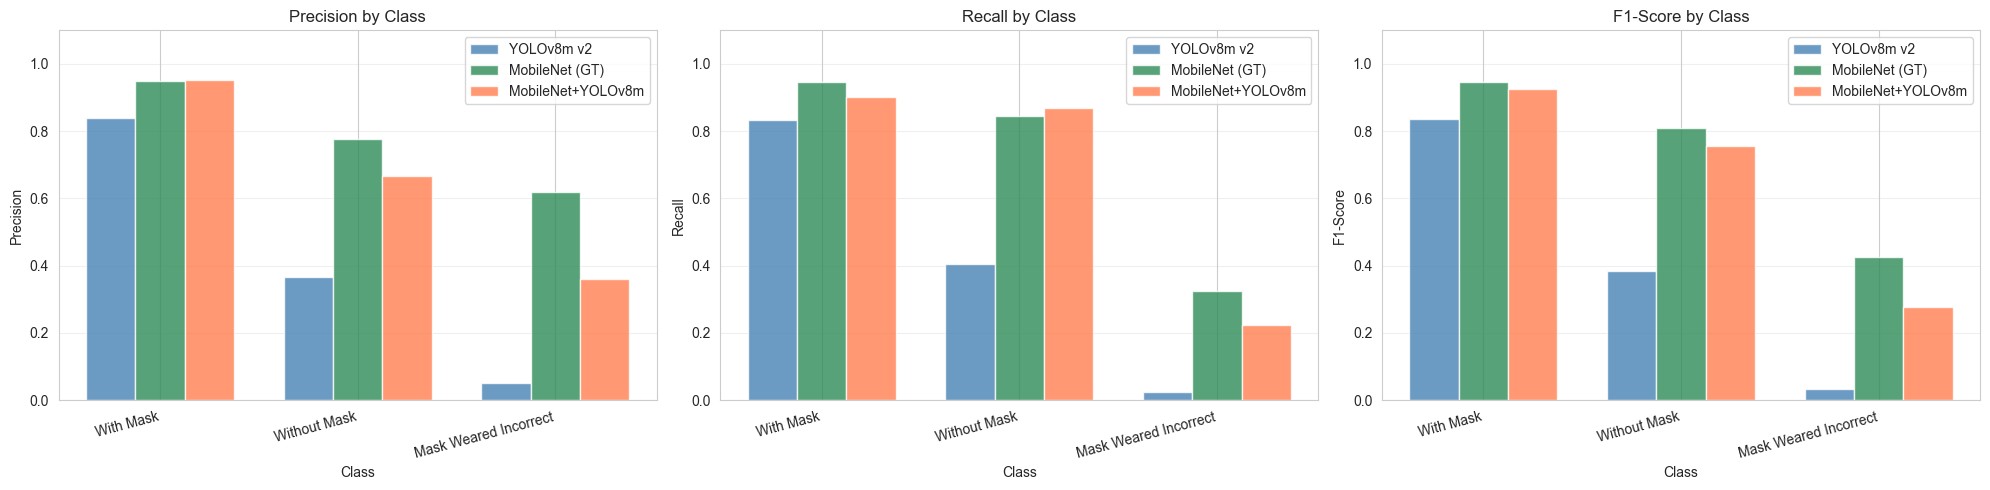

In [139]:
# Per-class comparison - Updated for 3 models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = ['Precision', 'Recall', 'F1-Score']
yolo_metrics = [yolo_precision_per_class, yolo_recall_per_class, yolo_f1_per_class]
mobilenet_metrics = [mobilenet_precision_per_class, mobilenet_recall_per_class, mobilenet_f1_per_class]
mobilenet_yolov8_metrics = [mobilenet_yolov8_precision_per_class, mobilenet_yolov8_recall_per_class, mobilenet_yolov8_f1_per_class]

for idx, (metric_name, yolo_vals, mobilenet_vals, mobilenet_yolov8_vals) in enumerate(zip(metrics, yolo_metrics, mobilenet_metrics, mobilenet_yolov8_metrics)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.25  # Changed from 0.35 to 0.25 to fit 3 bars
    
    # Ensure all classes are represented
    yolo_plot = np.zeros(len(CLASS_NAMES))
    mobilenet_plot = np.zeros(len(CLASS_NAMES))
    mobilenet_yolov8_plot = np.zeros(len(CLASS_NAMES))
    
    for i in range(len(CLASS_NAMES)):
        if i < len(yolo_vals):
            yolo_plot[i] = yolo_vals[i]
        if i < len(mobilenet_vals):
            mobilenet_plot[i] = mobilenet_vals[i]
        if i < len(mobilenet_yolov8_vals):
            mobilenet_yolov8_plot[i] = mobilenet_yolov8_vals[i]
    
    ax.bar(x - width, yolo_plot, width, label='YOLOv8m v2', alpha=0.8, color='steelblue')
    ax.bar(x, mobilenet_plot, width, label='MobileNet (GT)', alpha=0.8, color='seagreen')
    ax.bar(x + width, mobilenet_yolov8_plot, width, label='MobileNet+YOLOv8m', alpha=0.8, color='coral')
    
    ax.set_xlabel('Class')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} by Class')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()


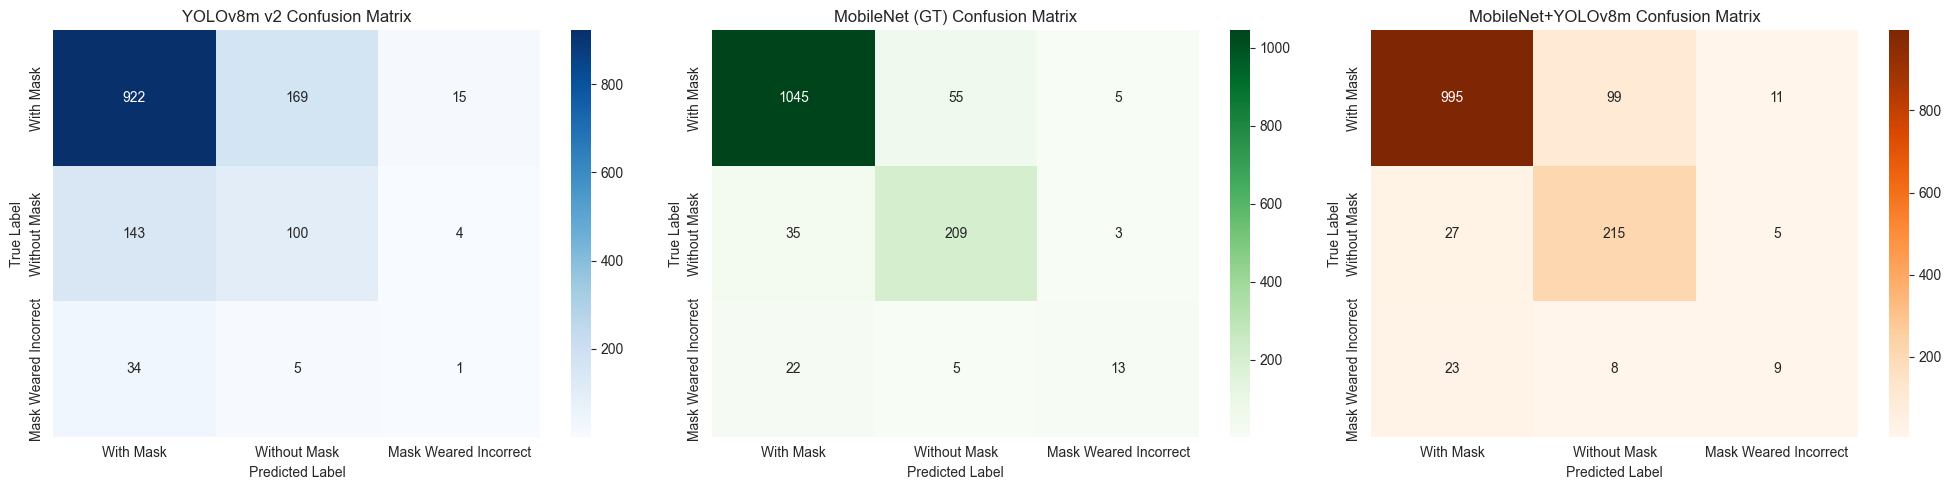

In [140]:
# Confusion Matrices for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# YOLOv8 Confusion Matrix
yolo_cm = confusion_matrix(yolo_y_true, yolo_y_pred)
sns.heatmap(yolo_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('YOLOv8m v2 Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# MobileNet (GT) Confusion Matrix
mobilenet_cm = confusion_matrix(mobilenet_y_true, mobilenet_y_pred)
sns.heatmap(mobilenet_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('MobileNet (GT) Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# MobileNet+YOLOv8m Confusion Matrix
mobilenet_yolov8_cm = confusion_matrix(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred)
sns.heatmap(mobilenet_yolov8_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[2].set_title('MobileNet+YOLOv8m Confusion Matrix')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


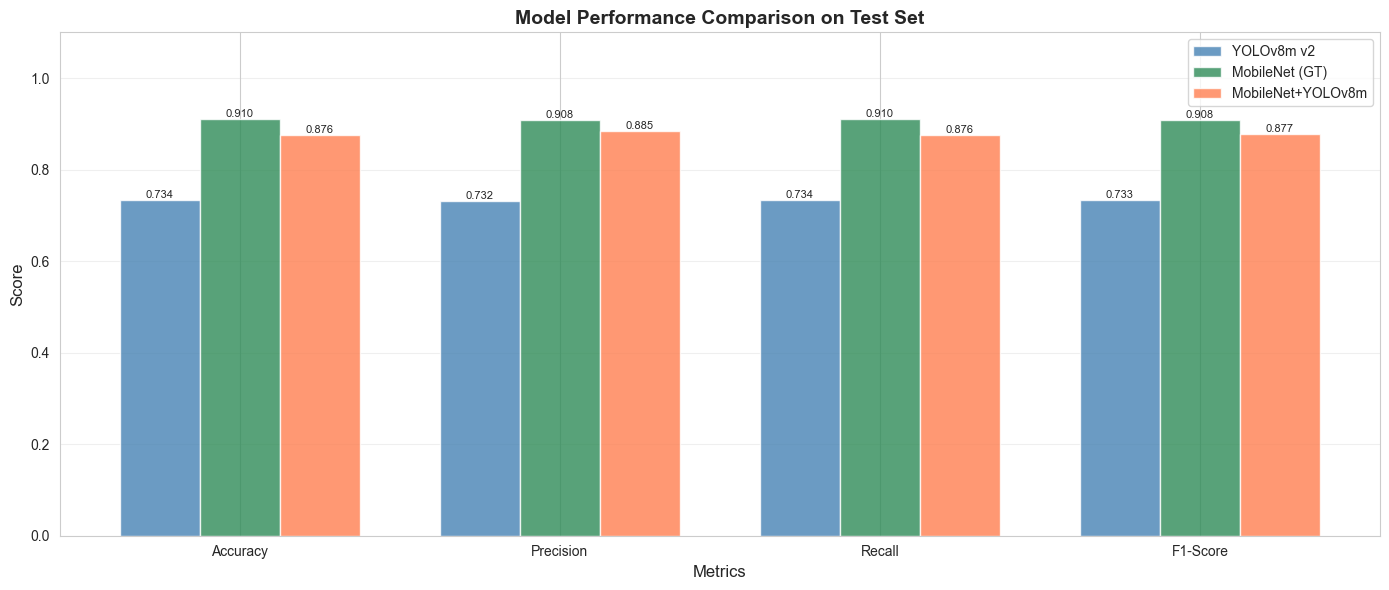

In [141]:
# Overall metrics comparison bar chart - Updated for 3 models
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
yolo_values = [yolo_accuracy, yolo_precision, yolo_recall, yolo_f1]
mobilenet_values = [mobilenet_accuracy, mobilenet_precision, mobilenet_recall, mobilenet_f1]
mobilenet_yolov8_values = [mobilenet_yolov8_accuracy, mobilenet_yolov8_precision, mobilenet_yolov8_recall, mobilenet_yolov8_f1]

x = np.arange(len(metrics_names))
width = 0.25  # Changed from 0.35 to 0.25 to fit 3 bars

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, yolo_values, width, label='YOLOv8m v2', alpha=0.8, color='steelblue')
bars2 = ax.bar(x, mobilenet_values, width, label='MobileNet (GT)', alpha=0.8, color='seagreen')
bars3 = ax.bar(x + width, mobilenet_yolov8_values, width, label='MobileNet+YOLOv8m', alpha=0.8, color='coral')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [142]:
# Detailed Classification Reports
print("="*80)
print("YOLOV8M V2 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(yolo_y_true, yolo_y_pred, target_names=CLASS_NAMES, zero_division=0))

print("\n" + "="*80)
print("MOBILENET (GT) CLASSIFICATION REPORT")
print("="*80)
print(classification_report(mobilenet_y_true, mobilenet_y_pred, target_names=CLASS_NAMES, zero_division=0))

print("\n" + "="*80)
print("MOBILENET+YOLOV8M CLASSIFICATION REPORT")
print("="*80)
print(classification_report(mobilenet_yolov8_y_true, mobilenet_yolov8_y_pred, target_names=CLASS_NAMES, zero_division=0))


YOLOV8M V2 CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.84      0.83      0.84      1106
         Without Mask       0.36      0.40      0.38       247
Mask Weared Incorrect       0.05      0.03      0.03        40

             accuracy                           0.73      1393
            macro avg       0.42      0.42      0.42      1393
         weighted avg       0.73      0.73      0.73      1393


MOBILENET (GT) CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.95      0.95      0.95      1105
         Without Mask       0.78      0.85      0.81       247
Mask Weared Incorrect       0.62      0.33      0.43        40

             accuracy                           0.91      1392
            macro avg       0.78      0.71      0.73      1392
         weighted avg       0.91      0.91      0.91      1392


MOBILENET+YOLOV8M CLASSIFICATION REPORT
